# Feature Selection Lab – Wine Classification (UCI Wine Dataset)

This notebook implements a complete feature selection workflow on the **UCI Wine** dataset,
using the built-in loader from scikit-learn.

Goal:  
Predict the cultivar (class) of a wine sample based on its chemical properties, and identify which features are most predictive.

The notebook covers:
- Data loading and basic exploratory analysis
- Train/test split and preprocessing (scaling)
- Baseline classification model
- Univariate feature selection
  - Pearson correlation (numeric features)
  - ANOVA F-test
- Model-based feature selection
  - L1-regularized logistic regression
  - Random forest feature importance
- Model performance comparison across feature subsets
- Confusion matrices and cross-validation for deeper evaluation


## 1. Environment Setup

In [1]:
# Install core libraries (safe to run in Colab or local)
# If they are already installed, this cell will finish quickly.

!pip install -q pandas numpy scikit-learn matplotlib seaborn

In [2]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.feature_selection import SelectKBest, f_classif

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

## 2. Data Loading and Problem Definition

In [3]:
# Load the UCI Wine dataset from scikit-learn

wine = load_wine(as_frame=True)

# wine.frame contains both features and target with column name 'target'
df = wine.frame.copy()

# For clarity, rename the target column
df = df.rename(columns={"target": "class"})
TARGET_COL = "class"

print("Dataset loaded from scikit-learn (UCI Wine).")
print("Shape:", df.shape)
print("Target column:", TARGET_COL)
display(df.head())

print("\nProblem: Predict the wine cultivar (class 0, 1, or 2) from chemical properties.")

Dataset loaded from scikit-learn (UCI Wine).
Shape: (178, 14)
Target column: class


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,class
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0



Problem: Predict the wine cultivar (class 0, 1, or 2) from chemical properties.


## 3. Basic Exploratory Data Analysis

In [4]:
# Overview of columns and data types
print("Column info:")
print(df.info())

Column info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   alcohol                       178 non-null    float64
 1   malic_acid                    178 non-null    float64
 2   ash                           178 non-null    float64
 3   alcalinity_of_ash             178 non-null    float64
 4   magnesium                     178 non-null    float64
 5   total_phenols                 178 non-null    float64
 6   flavanoids                    178 non-null    float64
 7   nonflavanoid_phenols          178 non-null    float64
 8   proanthocyanins               178 non-null    float64
 9   color_intensity               178 non-null    float64
 10  hue                           178 non-null    float64
 11  od280/od315_of_diluted_wines  178 non-null    float64
 12  proline                       178 non-null    float

Target value counts:
class
1    71
0    59
2    48
Name: count, dtype: int64


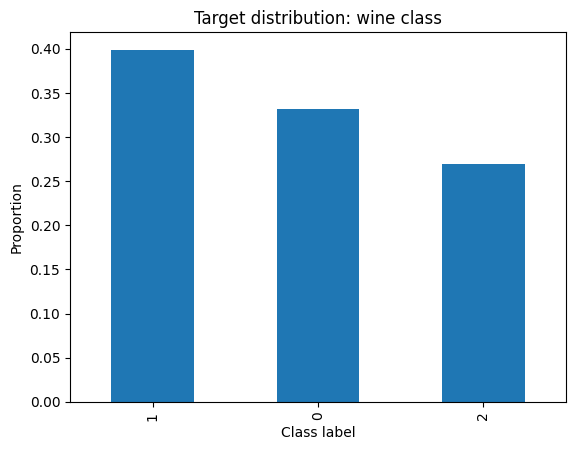

In [5]:
# Target distribution
print("Target value counts:")
print(df[TARGET_COL].value_counts())
df[TARGET_COL].value_counts(normalize=True).plot(kind="bar")
plt.title("Target distribution: wine class")
plt.xlabel("Class label")
plt.ylabel("Proportion")
plt.show()

In [6]:
# Summary statistics
display(df.describe().transpose())

,count,mean,std,min,25%,50%,75%,max
alcohol,178.0,13.000618,0.811827,11.03,12.3625,13.050,13.6775,14.83
malic_acid,178.0,2.336348,1.117146,0.74,1.6025,1.865,3.0825,5.80
ash,178.0,2.366517,0.274344,1.36,2.2100,2.360,2.5575,3.23
alcalinity_of_ash,178.0,19.494944,3.339564,10.60,17.2000,19.500,21.5000,30.00
magnesium,178.0,99.741573,14.282484,70.00,88.0000,98.000,107.0000,162.00
total_phenols,178.0,2.295112,0.625851,0.98,1.7425,2.355,2.8000,3.88
flavanoids,178.0,2.029270,0.998859,0.34,1.2050,2.135,2.8750,5.08
nonflavanoid_phenols,178.0,0.361854,0.124453,0.13,0.2700,0.340,0.4375,0.66
proanthocyanins,178.0,1.590899,0.572359,0.41,1.2500,1.555,1.9500,3.58
color_intensity,178.0,5.058090,2.318286,1.28,3.2200,4.690,6.2000,13.00


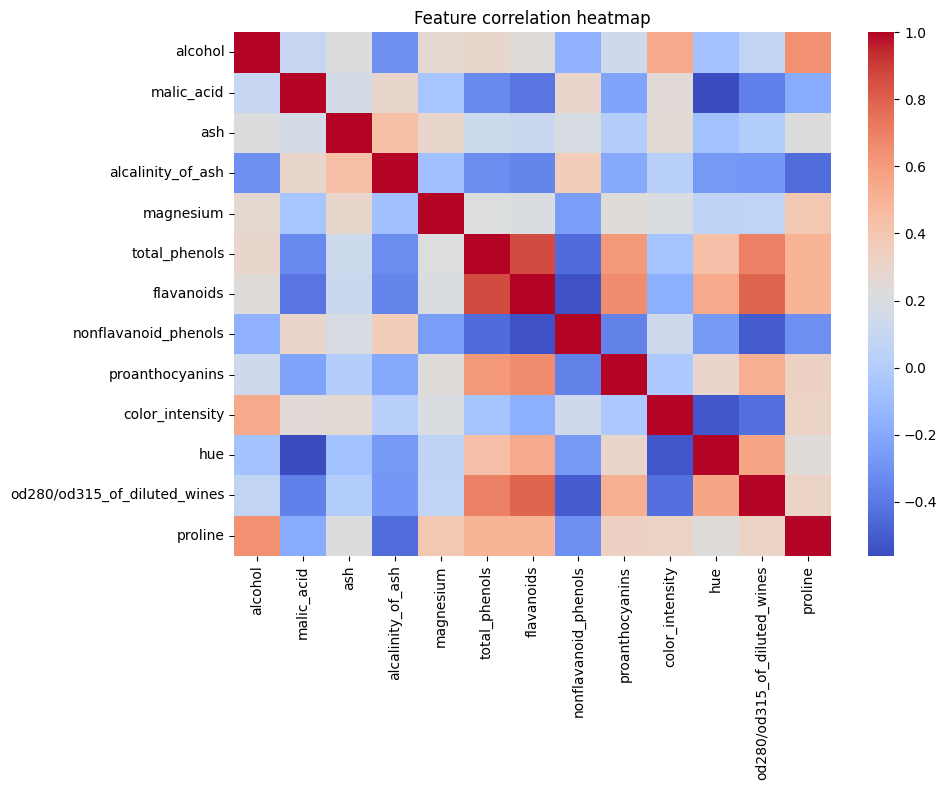

In [7]:
# Correlation heatmap for all numeric features
plt.figure(figsize=(10, 8))
corr_matrix = df.drop(columns=[TARGET_COL]).corr()
sns.heatmap(corr_matrix, cmap="coolwarm", annot=False)
plt.title("Feature correlation heatmap")
plt.tight_layout()
plt.show()

## 4. Train/Test Split and Preprocessing

We will:
- Separate features and target
- Split into train and test sets
- Standardize numeric features using `StandardScaler`

Note: this dataset is purely numeric, so there are no categorical features.

In [8]:
# Separate features and target
X = df.drop(columns=[TARGET_COL])
y = df[TARGET_COL]

# Train/test split (stratified to preserve class balance)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (142, 13)
Test shape: (36, 13)


In [9]:
# All predictors are numeric in this dataset
numeric_features = X.columns.tolist()
print("Numeric features:", numeric_features)

Numeric features: ['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline']


In [10]:
# Define preprocessing: scale numeric features
scaler = StandardScaler()

# Fit on training data only
scaler.fit(X_train)

X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaled training shape:", X_train_scaled.shape)
print("Scaled test shape:", X_test_scaled.shape)

Scaled training shape: (142, 13)
Scaled test shape: (36, 13)


## 5. Baseline Model (All Features, No Explicit Feature Selection)

We first create a baseline model using all available features after scaling.  
This serves as a reference point to compare with later models that use selected features only.

In [11]:
# Baseline multinomial logistic regression on all features
baseline_model = LogisticRegression(
    max_iter=2000,
    multi_class="multinomial",
    solver="lbfgs"
)
baseline_model.fit(X_train_scaled, y_train)

y_pred_base = baseline_model.predict(X_test_scaled)
y_proba_base = baseline_model.predict_proba(X_test_scaled)

baseline_accuracy = accuracy_score(y_test, y_pred_base)
baseline_f1 = f1_score(y_test, y_pred_base, average="macro")
try:
    baseline_roc = roc_auc_score(y_test, y_proba_base, multi_class="ovr")
except Exception:
    baseline_roc = np.nan

print("Baseline accuracy:", baseline_accuracy)
print("Baseline macro F1:", baseline_f1)
print("Baseline ROC-AUC (OvR):", baseline_roc)

print("\nClassification report (baseline):")
print(classification_report(y_test, y_pred_base))

Baseline accuracy: 0.9722222222222222
Baseline macro F1: 0.9709618874773139
Baseline ROC-AUC (OvR): 1.0

Classification report (baseline):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        12
           1       0.93      1.00      0.97        14
           2       1.00      0.90      0.95        10

    accuracy                           0.97        36
   macro avg       0.98      0.97      0.97        36
weighted avg       0.97      0.97      0.97        36



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


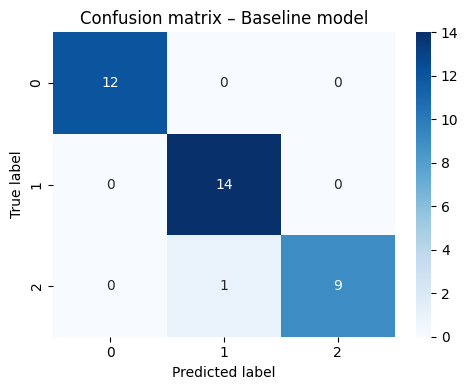

In [12]:
# Confusion matrix for the baseline model
cm_base = confusion_matrix(y_test, y_pred_base)

plt.figure(figsize=(5, 4))
sns.heatmap(cm_base, annot=True, fmt="d", cmap="Blues",
            xticklabels=np.unique(y), yticklabels=np.unique(y))
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("Confusion matrix – Baseline model")
plt.tight_layout()
plt.show()

## 6. Univariate Feature Selection

In this section we apply univariate methods to understand feature relevance individually:

- Pearson correlation between each numeric feature and the target (treated as numeric labels)
- ANOVA F-test for numeric features

This gives an initial ranking of features before considering interactions between them.

Top numeric features by absolute correlation with target:


,feature,pearson_corr_with_target,abs_corr
6,flavanoids,-0.847498,0.847498
11,od280/od315_of_diluted_wines,-0.788230,0.788230
5,total_phenols,-0.719163,0.719163
12,proline,-0.633717,0.633717
10,hue,-0.617369,0.617369
3,alcalinity_of_ash,0.517859,0.517859
8,proanthocyanins,-0.499130,0.499130
7,nonflavanoid_phenols,0.489109,0.489109
1,malic_acid,0.437776,0.437776
0,alcohol,-0.328222,0.328222


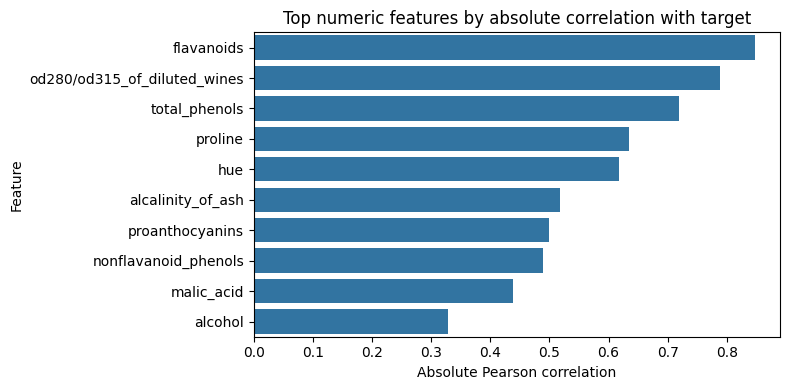

In [13]:
# 6.1 Pearson correlation (numeric features)

corr_values = []
for col in numeric_features:
    corr = np.corrcoef(df[col], df[TARGET_COL])[0, 1]
    corr_values.append((col, corr))

corr_df = pd.DataFrame(corr_values, columns=["feature", "pearson_corr_with_target"])
corr_df["abs_corr"] = corr_df["pearson_corr_with_target"].abs()
corr_df = corr_df.sort_values("abs_corr", ascending=False)

print("Top numeric features by absolute correlation with target:")
display(corr_df.head(10))

plt.figure(figsize=(8, max(4, len(corr_df) * 0.3)))
sns.barplot(data=corr_df.head(10), x="abs_corr", y="feature")
plt.title("Top numeric features by absolute correlation with target")
plt.xlabel("Absolute Pearson correlation")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

In [14]:
# 6.2 ANOVA F-test for numeric features

selector_anova = SelectKBest(score_func=f_classif, k=min(10, X_train.shape[1]))
selector_anova.fit(X_train, y_train)
anova_scores = selector_anova.scores_

anova_df = pd.DataFrame({
    "feature": numeric_features,
    "anova_f_score": anova_scores
}).sort_values("anova_f_score", ascending=False)

print("Top numeric features by ANOVA F-score:")
display(anova_df.head(10))

Top numeric features by ANOVA F-score:


,feature,anova_f_score
6,flavanoids,224.760551
12,proline,161.459538
11,od280/od315_of_diluted_wines,144.758527
9,color_intensity,103.897340
0,alcohol,98.468093
10,hue,79.531558
5,total_phenols,72.338568
1,malic_acid,29.088066
3,alcalinity_of_ash,27.518692
8,proanthocyanins,23.347278


## 7. Model-based Feature Selection

We now use supervised models to estimate feature importance in a multivariate setting:

- L1-regularized logistic regression (sparse coefficients)
- Random forest feature importance (Gini importance)

These methods consider interactions and redundancy between features, unlike purely univariate tests.

In [15]:
# 7.1 L1-regularized logistic regression on scaled features

l1_model = LogisticRegression(
    penalty="l1",
    solver="saga",
    max_iter=5000,
    multi_class="multinomial"
)
l1_model.fit(X_train_scaled, y_train)

# For multiclass, coefficients have shape (n_classes, n_features).
# Aggregate importance as maximum absolute coefficient over classes.
coef_matrix = l1_model.coef_
abs_coefs = np.abs(coef_matrix)
max_abs_coefs = abs_coefs.max(axis=0)

l1_df = pd.DataFrame({
    "feature": numeric_features,
    "max_abs_coef": max_abs_coefs
}).sort_values("max_abs_coef", ascending=False)

print("Top features by maximum absolute L1 coefficient:")
display(l1_df.head(10))

# Define a threshold to select non-zero coefficients
threshold = 1e-4
selected_features_l1 = l1_df[l1_df["max_abs_coef"] > threshold]["feature"].values

print("Number of features with non-zero coefficients (L1):", selected_features_l1.shape[0])
print("Selected features (L1):", selected_features_l1)

Top features by maximum absolute L1 coefficient:


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


,feature,max_abs_coef
6,flavanoids,2.308424
9,color_intensity,2.130071
0,alcohol,1.214156
12,proline,1.045420
2,ash,1.018283
3,alcalinity_of_ash,0.995266
11,od280/od315_of_diluted_wines,0.962141
10,hue,0.733623
1,malic_acid,0.614883
7,nonflavanoid_phenols,0.016802


Number of features with non-zero coefficients (L1): 10
Selected features (L1): ['flavanoids' 'color_intensity' 'alcohol' 'proline' 'ash'
 'alcalinity_of_ash' 'od280/od315_of_diluted_wines' 'hue' 'malic_acid'
 'nonflavanoid_phenols']


Top features by random forest importance:


,feature,importance
9,color_intensity,0.180805
6,flavanoids,0.172865
12,proline,0.151067
0,alcohol,0.112384
10,hue,0.099592
11,od280/od315_of_diluted_wines,0.090361
5,total_phenols,0.051563
1,malic_acid,0.033140
4,magnesium,0.032820
3,alcalinity_of_ash,0.026338


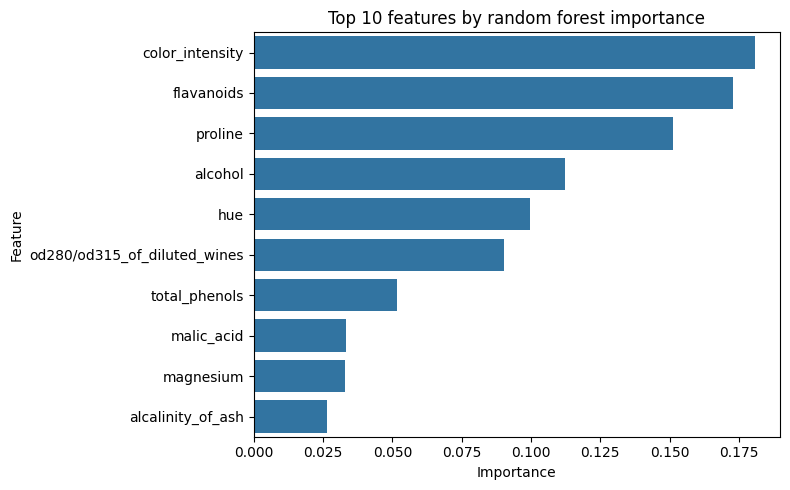

Number of top random forest features selected: 10
Selected features (RF): ['color_intensity' 'flavanoids' 'proline' 'alcohol' 'hue'
 'od280/od315_of_diluted_wines' 'total_phenols' 'malic_acid' 'magnesium'
 'alcalinity_of_ash']


In [16]:
# 7.2 Random forest feature importance on scaled features

rf_model = RandomForestClassifier(n_estimators=300, random_state=42)
rf_model.fit(X_train_scaled, y_train)

rf_importances = rf_model.feature_importances_
rf_df = pd.DataFrame({
    "feature": numeric_features,
    "importance": rf_importances
}).sort_values("importance", ascending=False)

print("Top features by random forest importance:")
display(rf_df.head(10))

plt.figure(figsize=(8, 5))
sns.barplot(data=rf_df.head(10), x="importance", y="feature")
plt.title("Top 10 features by random forest importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

# Select top-k features based on random forest importance
top_k = 10 if rf_df.shape[0] > 10 else rf_df.shape[0]
rf_top_features = rf_df.head(top_k)["feature"].values
print("Number of top random forest features selected:", len(rf_top_features))
print("Selected features (RF):", rf_top_features)

## 8. Model Comparison with Different Feature Subsets

We compare three models, all using multinomial logistic regression but trained on different feature sets:

1. Baseline: all scaled features (no explicit feature selection)
2. L1-selected: only features with non-zero L1 coefficients
3. Random forest top-k: only the top-k most important features from the random forest

In addition, we will:
- Plot confusion matrices for the best-performing model
- Use cross-validation to estimate performance more robustly

In [17]:
def evaluate_logistic_regression(X_train_subset, X_test_subset, y_train, y_test, label):
    model = LogisticRegression(
        max_iter=2000,
        multi_class="multinomial",
        solver="lbfgs"
    )
    model.fit(X_train_subset, y_train)
    y_pred = model.predict(X_test_subset)
    y_proba = model.predict_proba(X_test_subset)

    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average="macro")
    try:
        roc = roc_auc_score(y_test, y_proba, multi_class="ovr")
    except Exception:
        roc = np.nan

    print(f"{label} -> Accuracy: {acc:.4f}, Macro F1: {f1:.4f}, ROC-AUC (OvR): {roc:.4f}")
    return model, {
        "model": label,
        "accuracy": acc,
        "f1_macro": f1,
        "roc_auc_ovr": roc
    }

In [18]:
results = []

# Baseline (all features)
_, base_result = evaluate_logistic_regression(
    X_train_scaled, X_test_scaled, y_train, y_test, "Baseline (all features)"
)
results.append(base_result)

# L1-selected features
mask_l1 = np.isin(numeric_features, selected_features_l1)
X_train_l1 = X_train_scaled[:, mask_l1]
X_test_l1 = X_test_scaled[:, mask_l1]

model_l1, l1_result = evaluate_logistic_regression(
    X_train_l1, X_test_l1, y_train, y_test, "Logistic regression with L1-selected features"
)
results.append(l1_result)

# Random forest top-k features
mask_rf = np.isin(numeric_features, rf_top_features)
X_train_rf = X_train_scaled[:, mask_rf]
X_test_rf = X_test_scaled[:, mask_rf]

model_rf, rf_result = evaluate_logistic_regression(
    X_train_rf, X_test_rf, y_train, y_test, "Logistic regression with RF top-k features"
)
results.append(rf_result)

results_df = pd.DataFrame(results)
display(results_df)

Baseline (all features) -> Accuracy: 0.9722, Macro F1: 0.9710, ROC-AUC (OvR): 1.0000


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Logistic regression with L1-selected features -> Accuracy: 1.0000, Macro F1: 1.0000, ROC-AUC (OvR): 1.0000
Logistic regression with RF top-k features -> Accuracy: 1.0000, Macro F1: 1.0000, ROC-AUC (OvR): 1.0000


,model,accuracy,f1_macro,roc_auc_ovr
0,Baseline (all features),0.972222,0.970962,1.0
1,Logistic regression with L1-selected features,1.000000,1.000000,1.0
2,Logistic regression with RF top-k features,1.000000,1.000000,1.0


Best model based on macro F1: Logistic regression with L1-selected features


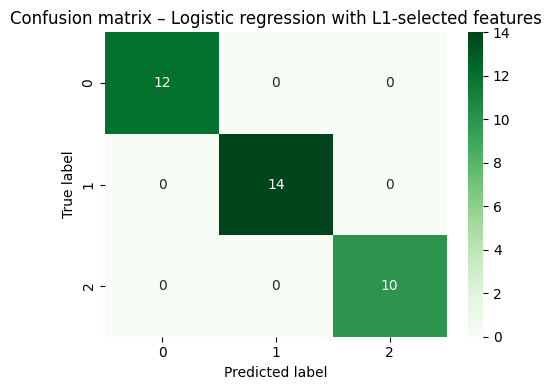

In [19]:
# Identify best model by macro F1
best_idx = results_df["f1_macro"].idxmax()
best_label = results_df.loc[best_idx, "model"]
print("Best model based on macro F1:", best_label)

if best_label == "Baseline (all features)":
    best_model = baseline_model
    X_train_best = X_train_scaled
    X_test_best = X_test_scaled
elif "L1-selected" in best_label:
    best_model = model_l1
    X_train_best = X_train_l1
    X_test_best = X_test_l1
else:
    best_model = model_rf
    X_train_best = X_train_rf
    X_test_best = X_test_rf

# Confusion matrix for the best model
y_pred_best = best_model.predict(X_test_best)
cm_best = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(5, 4))
sns.heatmap(cm_best, annot=True, fmt="d", cmap="Greens",
            xticklabels=np.unique(y), yticklabels=np.unique(y))
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title(f"Confusion matrix – {best_label}")
plt.tight_layout()
plt.show()

In [20]:
# Cross-validation on the best feature subset using 5-fold CV

print("5-fold cross-validation using the best feature subset (macro F1):")

X_best_full = np.vstack([X_train_best, X_test_best])
y_best_full = np.concatenate([y_train, y_test])

cv_model = LogisticRegression(
    max_iter=2000,
    multi_class="multinomial",
    solver="lbfgs"
)

cv_scores = cross_val_score(
    cv_model,
    X_best_full,
    y_best_full,
    cv=5,
    scoring="f1_macro"
)

print("CV macro F1 scores:", cv_scores)
print("Mean CV macro F1:", cv_scores.mean())
print("Std CV macro F1:", cv_scores.std())

5-fold cross-validation using the best feature subset (macro F1):
CV macro F1 scores: [1.         0.97178131 0.97096189 1.         1.        ]
Mean CV macro F1: 0.9885486385183905
Std CV macro F1: 0.014027389785707504


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and wi

## 9. Interpretation and Next Steps

At this point we have:

- A baseline multinomial logistic regression model using all available features
- Univariate analysis of feature relevance (correlation, ANOVA)
- Model-based feature importance estimates from L1 logistic regression and random forest
- Quantitative comparison of models using different feature subsets
- Confusion matrices and cross-validated performance estimates for the best feature subset

Next steps:
- Trying alternative classifiers (for example, gradient boosting methods or support vector machines)
- Exploring interactions or nonlinear transformations of key features
- Applying dimensionality reduction techniques such as PCA and comparing results
